#### Import the libraries 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

#### Load the dataset and add headers

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [3]:
print("Movies Shape :", movies.shape)
print("Ratings Shape :", ratings.shape)

Movies Shape : (9742, 3)
Ratings Shape : (100836, 4)


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


#### Missing Values

In [6]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [7]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

#### Duplicate Values

In [8]:
movies.duplicated().sum()

np.int64(0)

In [9]:
ratings.duplicated().sum()

np.int64(0)

#### Data Information

In [10]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [11]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


#### Merge Data

In [12]:
movie_data = pd.merge(
    ratings,
    movies,
    on="movieId"
)

movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


#### Create User Movie Matrix

In [13]:
user_movie_matrix = movie_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

user_movie_matrix = user_movie_matrix.fillna(0)

user_movie_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Collaborative Filtering

In [14]:
user_similarity = cosine_similarity(user_movie_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

#### Content-Based Features

In [15]:
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(
    movies['genres']
)

content_similarity = cosine_similarity(
    tfidf_matrix
)

#### Movie Index

In [16]:
indices = pd.Series(
    movies.index,
    index=movies['title']
).drop_duplicates()

## Content Based Recommendation

In [17]:
def content_scores(movie_title):

    idx = indices[movie_title]

    similarity = list(
        enumerate(content_similarity[idx])
    )

    similarity = sorted(
        similarity,
        key=lambda x:x[1],
        reverse=True
    )

    return similarity

### Collaborative Recommendation

In [18]:
def collaborative_scores(user_id):

    similar_users = user_similarity_df[user_id].sort_values(
        ascending=False
    )[1:11]

    weighted = pd.Series(dtype=float)

    for user,score in similar_users.items():

        weighted = weighted.add(
            user_movie_matrix.loc[user]*score,
            fill_value=0
        )

    return weighted

# Recommendation Function

In [19]:
def hybrid_recommendation(
        user_id,
        movie_title,
        top_n=10,
        alpha=0.5):

    collaborative = collaborative_scores(user_id)

    content = content_scores(movie_title)

    hybrid_scores = {}

    for idx,content_score in content:

        title = movies.iloc[idx]['title']

        collab_score = collaborative.get(
            title,
            0
        )

        score = (
            alpha*content_score
            +
            (1-alpha)*collab_score
        )

        hybrid_scores[title] = score

    recommendations = pd.DataFrame(

        hybrid_scores.items(),

        columns=[
            'Movie',
            'Hybrid Score'
        ]
    )

    recommendations = recommendations.sort_values(
        'Hybrid Score',
        ascending=False
    )

    return recommendations.head(top_n)

In [20]:
user_id = 5

movie = "Toy Story (1995)"

hybrid_recommendation(
    user_id,
    movie,
    top_n=10
)

,Movie,Hybrid Score
2963,Apollo 13 (1995),10.362736
4954,Forrest Gump (1994),9.923089
2890,Dances with Wolves (1990),9.900705
5271,"Fugitive, The (1993)",9.848352
4717,Pulp Fiction (1994),9.673442
1572,True Lies (1994),9.309881
5211,"Shawshank Redemption, The (1994)",9.118291
5302,Schindler's List (1993),9.011381
5237,Speed (1994),8.485648
813,"Lion King, The (1994)",7.963594


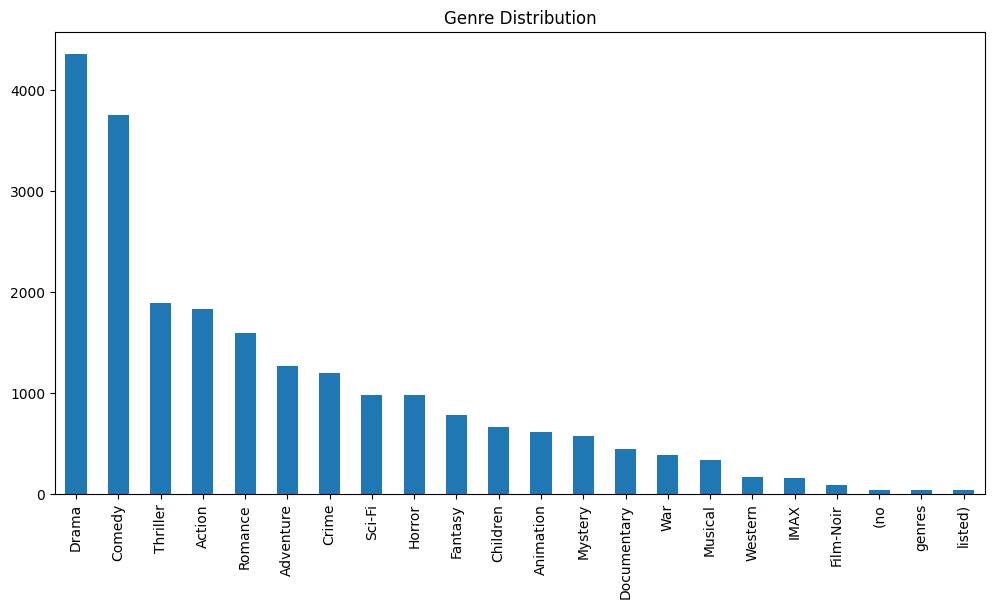

In [21]:
genre_count = movies['genres'].str.get_dummies(
    sep=' '
).sum()

plt.figure(figsize=(12,6))

genre_count.sort_values(
    ascending=False
).plot(kind='bar')

plt.title("Genre Distribution")

plt.show()

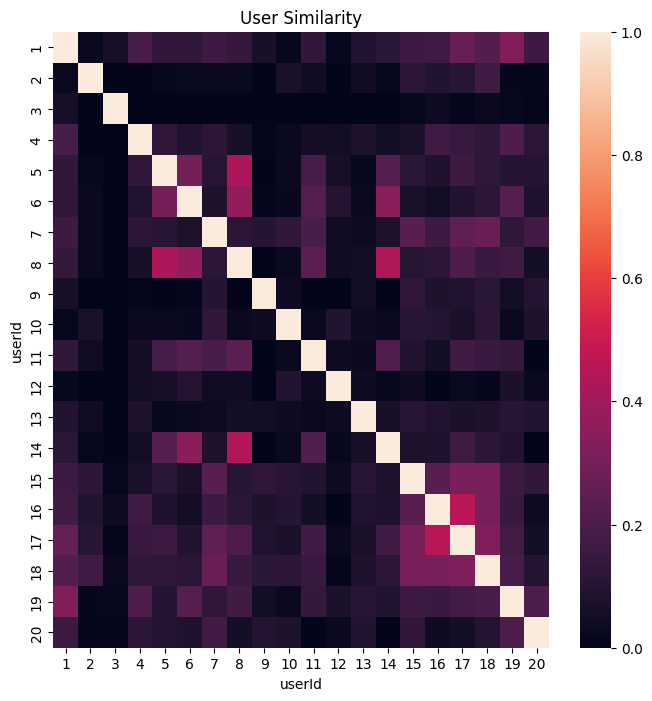

In [22]:
plt.figure(figsize=(8,8))

sns.heatmap(
    user_similarity_df.iloc[:20,:20]
)

plt.title("User Similarity")

plt.show()

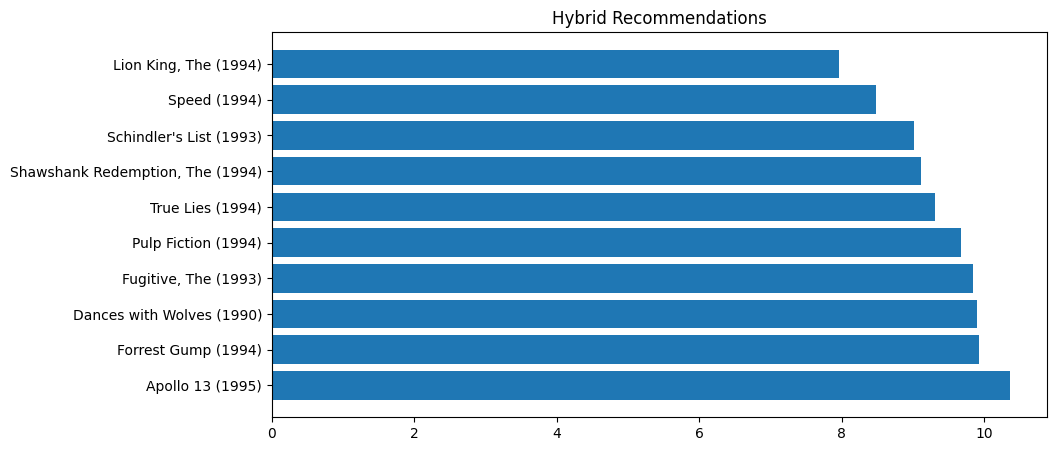

In [23]:
result = hybrid_recommendation(
    5,
    "Toy Story (1995)"
)

plt.figure(figsize=(10,5))

plt.barh(
    result['Movie'],
    result['Hybrid Score']
)

plt.title("Hybrid Recommendations")

plt.show()